--- Initial Inspection ---
Dataset Shape: (891, 12)

Missing Values Before Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicates removed: 0

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_1316/2514014601.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Sex", y="Survived", palette="Blues_d")


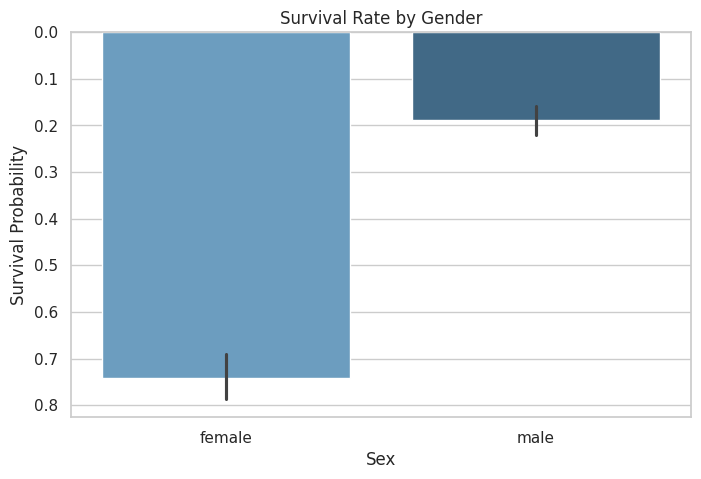

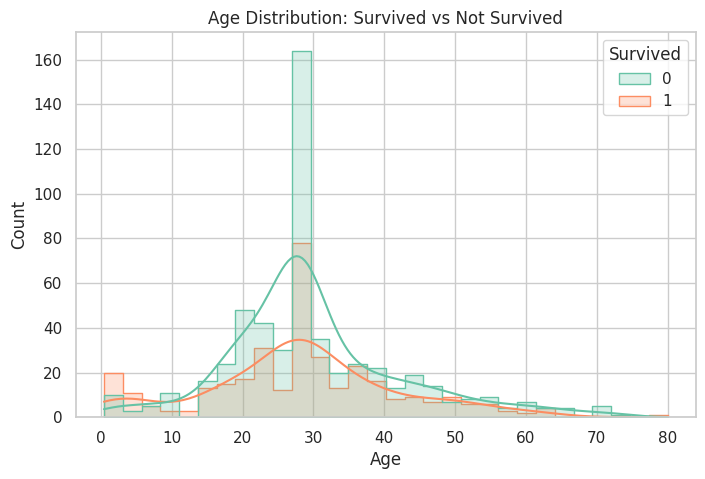

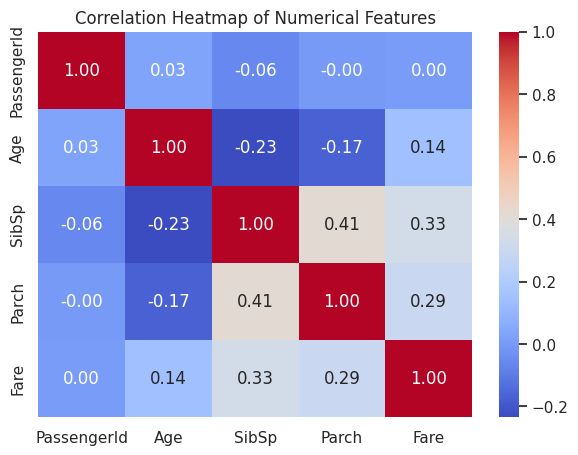

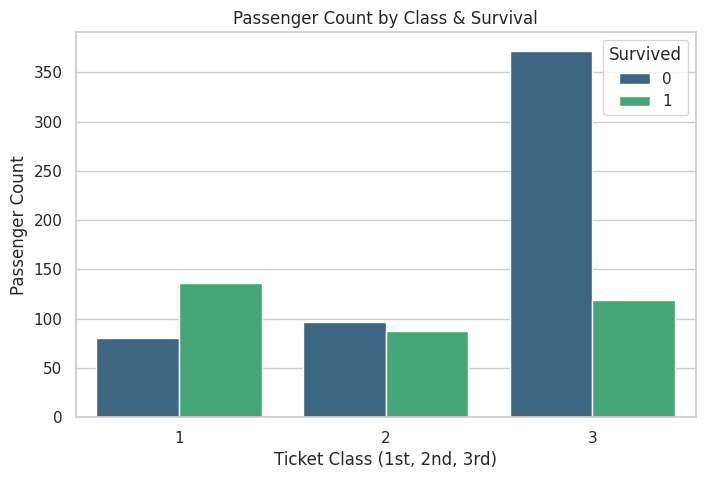


Cleaned data saved as 'titanic_cleaned.csv'.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# 1. Load Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("--- Initial Inspection ---")
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# 2. Data Cleaning
# a. Handle Missing Values
# Impute Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Impute Embarked with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin due to high missing rate (>75%)
df.drop(columns=["Cabin"], inplace=True)

# b. Remove Duplicates (if any)
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"\nDuplicates removed: {initial_rows - len(df)}")

# c. Handle Outliers in 'Fare' using IQR method
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

# Cap Fare outliers to upper threshold rather than dropping
df["Fare"] = np.where(df["Fare"] > upper_limit, upper_limit, df["Fare"])

# d. Correct Data Types
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# 3. Data Visualization & Insights

# Chart 1: Survival Rate by Gender
plt.figure()
sns.barplot(data=df, x="Sex", y="Survived", palette="Blues_d")
plt.title("Survival Rate by Gender")
plt.xlabel("Sex")
plt.ylabel("Survival Probability")
plt.savefig("survival_by_gender.png", bbox_inches="tight")
plt.show()

# Chart 2: Age Distribution by Survival Status
plt.figure()
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    kde=True,
    element="step",
    palette="Set2",
)
plt.title("Age Distribution: Survived vs Not Survived")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("age_distribution.png", bbox_inches="tight")
plt.show()

# Chart 3: Correlation Heatmap for Numerical Features
plt.figure(figsize=(7, 5))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Chart 4: Survival by Passenger Class
plt.figure()
sns.countplot(data=df, x="Pclass", hue="Survived", palette="viridis")
plt.title("Passenger Count by Class & Survival")
plt.xlabel("Ticket Class (1st, 2nd, 3rd)")
plt.ylabel("Passenger Count")
plt.savefig("survival_by_class.png", bbox_inches="tight")
plt.show()

# Save Cleaned Data
df.to_csv("titanic_cleaned.csv", index=False)
print("\nCleaned data saved as 'titanic_cleaned.csv'.")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful